In [173]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [174]:
df = pd.read_csv('train_data.csv')
df.head(5)

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,f_185,f_186,f_187,f_188,f_189,f_190,f_191,f_192,f_193,class
0,0.0,16.0,222558.0,254604.0,0.0,0.0,1948202.0,3.735399e+06,6710.0,70020.0,...,965724.0,1202.0,0.0,45580.0,NaN,NaN,NaN,0.0,0.0,pos
1,0.0,159760.0,2000720.0,211034.0,NaN,1640.0,4160.0,2.236096e+07,310712.0,NaN,...,717646.0,432170.0,NaN,99988.0,NaN,NaN,NaN,0.0,NaN,pos
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neg
3,0.0,22.0,25756.0,55458.0,0.0,0.0,0.0,7.838146e+05,6272.0,101070.0,...,81884.0,0.0,0.0,7292.0,NaN,643384.748708,1350.0,0.0,0.0,neg
4,0.0,304966.0,714748.0,5740.0,0.0,5940.0,76230.0,1.826465e+06,590678.0,96232.0,...,704232.0,0.0,0.0,2074.0,1724.0,NaN,NaN,0.0,0.0,pos


### Null cleaning

<Axes: ylabel='Count'>

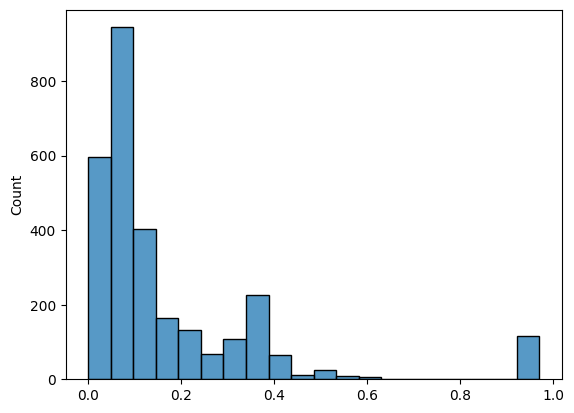

In [175]:
na_counts = df.isna().sum(axis=1)/len(df.columns)
na_counts = na_counts.sort_values(ascending=False)
sns.histplot(na_counts, bins=20)

In [176]:
df = df.drop(na_counts[na_counts>0.45].index)

<Axes: ylabel='Count'>

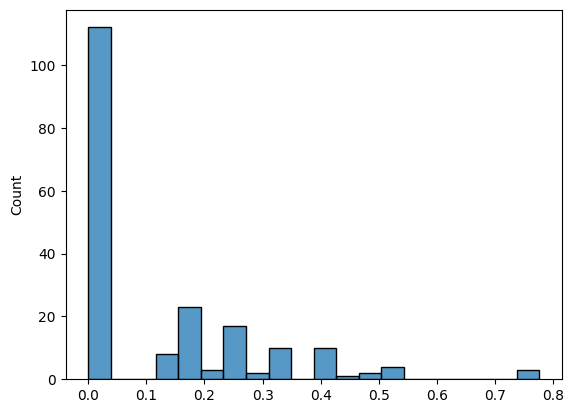

In [177]:
na_counts = df.isna().sum()/len(df)
na_counts = na_counts.sort_values(ascending=False)
sns.histplot(na_counts, bins=20)

In [178]:
col_indexes = na_counts[na_counts>0.6].index
df = df.drop(col_indexes, axis=1)

In [179]:
df.shape

(2703, 192)

### Feature selection

In [180]:
imputer = SimpleImputer(strategy="median")
df_imputed = imputer.fit_transform(df.drop('class', axis=1))
df_imputed = pd.DataFrame(df_imputed, columns=df.drop('class', axis=1).columns)

indexes = ['f_171', 'f_17', 'f_22', 'f_43', 'f_151', 'f_83']
df_imputed = df_imputed.drop(indexes, axis=1)

<Axes: >

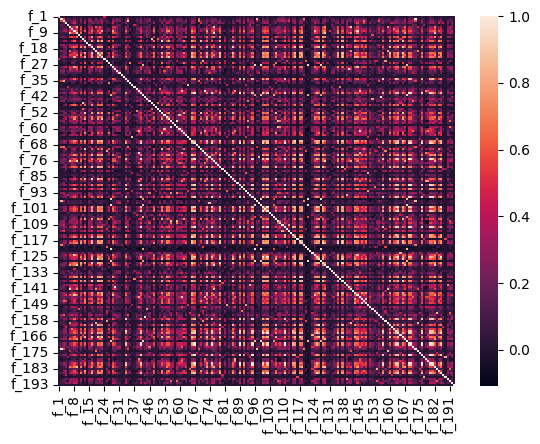

In [181]:
sns.heatmap(df_imputed.corr())

<Axes: ylabel='Count'>

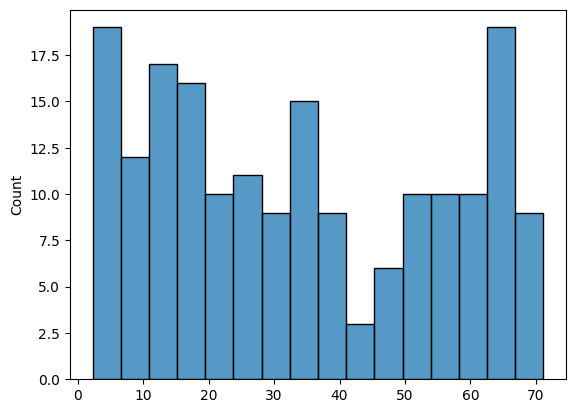

In [182]:
corr_cols = df_imputed.corr().abs().sum().sort_values(ascending=False)
sns.histplot(corr_cols, bins=16)

<Axes: ylabel='Count'>

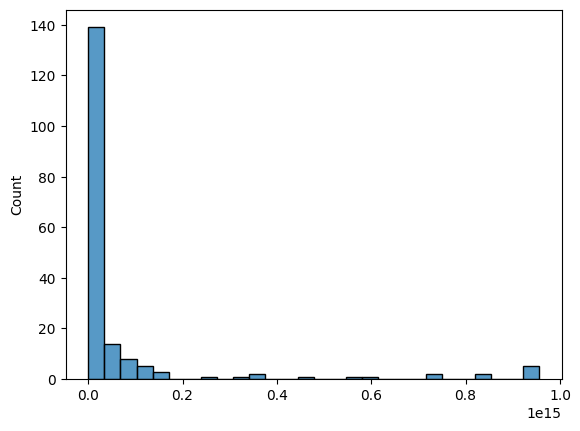

In [183]:
sns.histplot(df_imputed.var())

In [184]:
df_imputed.columns[df_imputed.var().argmax()]

'f_75'

<Axes: ylabel='Count'>

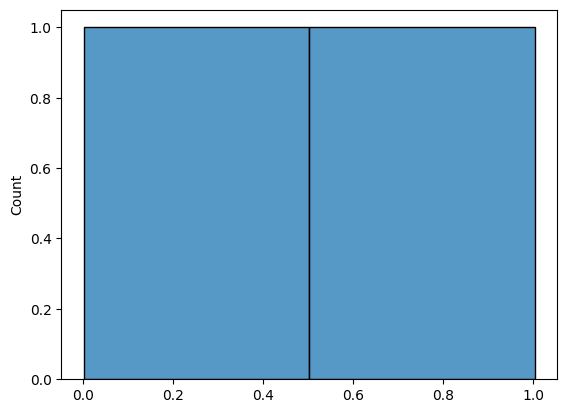

In [185]:
var = df_imputed.var()
sns.histplot(var[var < 10])

In [186]:
var.min(), df_imputed.columns[var.argmin()]

(np.float64(0.0014815302297823073), 'f_136')

### other

In [187]:
df_test = pd.read_csv('test_data.csv')

df = df.drop(indexes, axis=1, errors='ignore')
df['class'] = df['class'].map({'pos': 1, 'neg': 0})
df_test['class'] = df_test['class'].map({'pos': 1, 'neg': 0})

x_test = df_test.drop(col_indexes, axis=1).drop(indexes, axis=1).drop('class', axis=1)
y_test = df_test['class']

In [188]:
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
        max_depth=None,
        min_samples_leaf=1,
    )),
])

x = df.drop('class', axis=1)
pipeline.fit(x, df['class'])
preds = pipeline.predict(x_test)
f1_score(y_test, preds)

0.9174311926605505